## <span style="color:blue"> Lezione 12 </span>



In [24]:

import tensorflow as tf
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Dense, Dropout,Flatten, Conv2D, MaxPooling2D,Input
from keras.optimizers import SGD,Adam,Adagrad

from PIL import Image
import os

import numpy as np
import matplotlib.pyplot as plt



np.random.seed(0) 
tf.random.set_seed(0)




Si ha a disposizione un dataset (Mnist,importato da Keras), contenente immagini 28x28 pixel a sfondo nero di cifre da 0 a 9 scritte in bianco. Ciascuna è etichettata con la cifra corrispondente. Si vuole creare una rete neurale in grado di riconoscere dall'immagine di una cifra (rispettante i criteri del dataset), quale cifra essa sia. Si tratta, quindi di un problema di classificazione. 

La cella sottostante carica i dati. La divisione in dati di training e dati di test viene fatta automaticamente. 

In [25]:
from keras.datasets import mnist


# input image dimensions
img_rows, img_cols = 28, 28 # number of pixels 


# the data, split between train and test sets
(X_train, Y_train), (X_test, Y_test) = mnist.load_data()

print('X_train shape:', X_train.shape)
print('X_test shape:', X_test.shape)


# cast to floats
X_train = X_train.astype('float32')
X_test = X_test.astype('float32')

# rescale data in interval [0,1]
X_train /= 255
X_test /= 255


X_train shape: (60000, 28, 28)
X_test shape: (10000, 28, 28)


Come si può vedere dall'output della cella sovrastante, $X_{\mathrm{train}}$ e $X_{\mathrm{test}}$ sono vettori di, rispettivamente, $N_{\mathrm{train}}=60000$ e $N_{\mathrm{test}}=10000$  matrici 28x28, che vengono opportunatamente normalizzate (di modo che ogni entrata sia un numero compreso tra 0 e 1). 

$Y_{\mathrm{train}}$ e $Y_{\mathrm{test}}$, invece, contengono $N=60000$ etichette ("0",...,"9"). Ciascuna di esse viene convertita dalla cella sottostante in un vettore di dimensione $10$ (le cifre sono dieci). 
Ad esempio, l'etichetta "5" viene convertita nel vettore [0. 0.  0. 0. 0. 1. 0. 0. 0. 0.], che ha un unico uno in corrispondenza dell'indice 5. 

In [26]:

# output
num_classes = 10 # 10 digits


# convert class vectors to binary class matrices, e.g. for use with categorical_crossentropy

Y_train = keras.utils.to_categorical(Y_train, num_classes)

Y_test = keras.utils.to_categorical(Y_test, num_classes)



Le etichette così espresse, possono essere utilizzate per calcolare la funzione _cross-entropy_. 
Inizieremo col definirla per un problema di classificazione binaria. 
Sia un dataset con $N$ coppie $(x_i,Y_i)$, dove l'etichetta $Y_i$ può assumere i soli valori $0,1$. La cross-entropy è: $$ E(\vec{w})=-\sum_{i=1}^N Y_i \log(f(x_i,\vec{W})) + (1-Y_i) \log(1-f(x_i,\vec{w})) $$ 
dove con $\vec{w}$ si indicano i pesi del modello e con $f(x_i,\vec{w})$ la predizione del modello sull' input $x_i$.

$f(x_i,\vec{w})$ sarà un numero compreso tra $0$ e $1$, che, per un buon modello, è molto vicino a $0$ per tutti quegli $i$ per cui $Y_i=0$, mentre si avvicina ad $1$ per tutti i $k$ per cui $Y_k$. Per cui, per un buon modello, $ E(\vec{w}) \sim 0$, mentre $ E(\vec{w}) >0 $ in tutti gli altri casi. 


Estendendo al caso con $M$ classi, ciascun $Y_i$ diventa un vettore di dimensione $M$. Le sue entrate $Y_{ij}$ sono tutte zero tranne l'm-esima, che rappresenta la categoria a cui appartiene $x_i$. Anche la funzione $f$ restituirà come output un vettore di dimensione $M$. In un buon modello, $f_j(x_i,\vec{w}) \sim Y_{ij}$.
La funzione cross-entropy diventa quindi: $$  E(\vec{w})=-\sum_{i=1}^{N} \sum_{j=1}^M Y_{ij} \log(f_j(x_i,\vec{w})).$$ 


Essa verrà usata come funzione costo per stimare la predittività del modello. 


### <span style="color:DodgerBlue"> Esercizio 12.1 </span>

## Rete neurale DNN

Innanzitutto si affronta il problema con una Deep Neural Network (introdotte nell'esercitazione precedente). 


Rispetto all'esercitazione precedente, viene introdotto un nuovo tipo di layer: il _dropout layer_ che, eliminando casualmente le connessioni tra alcuni neuroni (la percentuale di connessioni da eliminare è passata come parametro),riduce il rischio di overfitting impedendo alla rete di imparare accidentali schemi nei dati. 

L'output avrà dimensione $10$, corrispondente alle $10$ classi. In input, invece, la rete prenderà le immagini appiattite in un vettore di $N_{\mathrm{pixel}}=28 \cdot 28=784$ elementi.

A questo proposito,la forma di $X_{\mathrm{train}}$ e $X_{\mathrm{test}}$ viene opportutamente modificata nella cella sottostante. 

In [27]:

X_train_DNN = X_train.reshape(X_train.shape[0], img_rows*img_cols)
X_test_DNN = X_test.reshape(X_test.shape[0], img_rows*img_cols)
print('X_train shape:', X_train_DNN.shape)
print('X_test shape:', X_test_DNN.shape)


X_train shape: (60000, 784)
X_test shape: (10000, 784)


La cella sottostante contiene il codice per costruire la rete neurale. Essa prende in input un optimizer, che viene passato come parametro alla funzione che compila il modello. 

In [28]:

def create_DNN(optimizer):

    # create the model


    # instantiate model
    model = Sequential()
    model.add(Input(shape=(img_rows*img_cols,)))
    # add a dense all-to-all relu layer
    model.add(Dense(400, activation='relu'))
    # add a dense all-to-all relu layer
    model.add(Dense(100, activation='relu'))
    # apply dropout with rate 0.5
    model.add(Dropout(0.5))
    # soft-max layer
    model.add(Dense(num_classes, activation='softmax'))
    
    # compile the model
    model.compile(loss=keras.losses.categorical_crossentropy,
                  optimizer=optimizer,
                  metrics=['acc'])
    return model



Sono stati usati tre optimizer diversi:

- SGD con i parametri di default (_vanilla gradient descent_). Dato $w$ un parametro con gradiente $g$, la legge di aggiornamento per $w$ è
$w'= w - R_l g$, con $R_l=0.01$ learning rate. 

- Adam, sempre coi parametri di default. Come SGD implementa il metodo dello _stochastic gradient descent_. Si basa sul calcolo di momenti al primo e secondo ordine nel gradiente $g$. 

- Adagrad, con learning rate (principale) $R_l=0.1$. È un ottimizzatore che permette di avere learing rate specifiche per i singoli parametri, che vengono adattate in base alla frequenza di aggiustamento del parametro durante il training: più aggiustamenti riceve, più piccoli saranno. 


Si metteranno a confronto le loro performance. 

In [29]:
# training parameters
batch_size = 64
epochs = 40

### SGD

In [30]:

# create the deep neural net
model_DNN_1 = create_DNN(SGD())
model_DNN_1.summary()

# train DNN and store training info in history
history_DNN_1 = model_DNN_1.fit(X_train_DNN, Y_train,
          batch_size=batch_size,
          epochs=epochs,
          shuffle=True, # a good idea is to shuffle input before at each epoch
          verbose=1,
          validation_data=(X_test_DNN, Y_test))



Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 400)            │       314,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 100)            │        40,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 355,110 (1.35 MB)

 Trainable params: 355,110 (1.35 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/40
938/938 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - acc: 0.7016 - loss: 1.0114 - val_acc: 0.8940 - val_loss: 0.4160
Epoch 2/40
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - acc: 0.8576 - loss: 0.4936 - val_acc: 0.9151 - val_loss: 0.3114
Epoch 3/40
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - acc: 0.8866 - loss: 0.4002 - val_acc: 0.9255 - val_loss: 0.2673
Epoch 4/40
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - acc: 0.9007 - loss: 0.3503 - val_acc: 0.9323 - val_loss: 0.2382
Epoch 5/40
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - acc: 0.9109 - loss: 0.3162 - val_acc: 0.9385 - val_loss: 0.2167
Epoch 6/40
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - acc: 0.9180 - loss: 0.2927 - val_acc: 0.9430 - val_loss: 0.2006
Epoch 7/40
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - acc: 0.9256 - loss: 0.2696 - val_acc: 0.9473 - val_loss: 0.1871
Epoch 8/40
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - acc: 0.9295 - loss: 0.2525 - val_acc: 0.9495 - val_loss: 0.1751
Epoch 9/40
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - ac

### Adam

In [31]:

# create the deep neural net
model_DNN_2 = create_DNN(Adam())
model_DNN_2.summary()

# train DNN and store training info in history
history_DNN_2 = model_DNN_2.fit(X_train_DNN, Y_train,
          batch_size=batch_size,
          epochs=epochs,
          shuffle=True, # a good idea is to shuffle input before at each epoch
          verbose=1,
          validation_data=(X_test_DNN, Y_test))

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_15 (Dense)                │ (None, 400)            │       314,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 100)            │        40,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 355,110 (1.35 MB)

 Trainable params: 355,110 (1.35 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/40
938/938 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - acc: 0.9070 - loss: 0.3171 - val_acc: 0.9631 - val_loss: 0.1199
Epoch 2/40
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - acc: 0.9618 - loss: 0.1330 - val_acc: 0.9734 - val_loss: 0.0892
Epoch 3/40
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - acc: 0.9728 - loss: 0.0929 - val_acc: 0.9767 - val_loss: 0.0821
Epoch 4/40
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - acc: 0.9796 - loss: 0.0697 - val_acc: 0.9776 - val_loss: 0.0763
Epoch 5/40
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - acc: 0.9830 - loss: 0.0556 - val_acc: 0.9779 - val_loss: 0.0815
Epoch 6/40
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - acc: 0.9857 - loss: 0.0464 - val_acc: 0.9802 - val_loss: 0.0767
Epoch 7/40
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - acc: 0.9878 - loss: 0.0387 - val_acc: 0.9813 - val_loss: 0.0776
Epoch 8/40
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - acc: 0.9896 - loss: 0.0323 - val_acc: 0.9759 - val_loss: 0.0976
Epoch 9/40
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - ac

### AdaGrad

In [32]:
# create the deep neural net
model_DNN_3 = create_DNN(Adagrad(learning_rate=0.1))
model_DNN_3.summary()

# train DNN and store training info in history
history_DNN_3 = model_DNN_3.fit(X_train_DNN, Y_train,
          batch_size=batch_size,
          epochs=epochs,
          shuffle=True, # a good idea is to shuffle input before at each epoch
          verbose=1,
          validation_data=(X_test_DNN, Y_test))

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_18 (Dense)                │ (None, 400)            │       314,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 100)            │        40,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 355,110 (1.35 MB)

 Trainable params: 355,110 (1.35 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/40
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - acc: 0.9024 - loss: 0.3234 - val_acc: 0.9479 - val_loss: 0.1699
Epoch 2/40
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - acc: 0.9613 - loss: 0.1382 - val_acc: 0.9720 - val_loss: 0.0933
Epoch 3/40
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - acc: 0.9713 - loss: 0.0969 - val_acc: 0.9757 - val_loss: 0.0802
Epoch 4/40
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - acc: 0.9778 - loss: 0.0755 - val_acc: 0.9786 - val_loss: 0.0720
Epoch 5/40
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - acc: 0.9819 - loss: 0.0594 - val_acc: 0.9799 - val_loss: 0.0680
Epoch 6/40
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - acc: 0.9849 - loss: 0.0495 - val_acc: 0.9808 - val_loss: 0.0664
Epoch 7/40
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - acc: 0.9871 - loss: 0.0411 - val_acc: 0.9810 - val_loss: 0.0674
Epoch 8/40
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - acc: 0.9895 - loss: 0.0353 - val_acc: 0.9822 - val_loss: 0.0674
Epoch 9/40
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - ac

La cella sottostante valuta 

In [33]:
optimizers=["SGD","Adam","Adagrad"]
models_DNN=[model_DNN_1,model_DNN_2,model_DNN_3]
histories_DNN=[history_DNN_1,history_DNN_2,history_DNN_3]


for i,optimizer in enumerate(optimizers):
    # evaluate model
    score = models_DNN[i].evaluate(X_test_DNN, Y_test, verbose=1)
    # print performance
    print("Optimizer: ",optimizer)
    print('Test loss:', score[0])
    print('Test accuracy:', score[1],"\n")


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - acc: 0.9774 - loss: 0.0747
Optimizer:  SGD
Test loss: 0.07465191185474396
Test accuracy: 0.977400004863739 

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - acc: 0.9821 - loss: 0.1585
Optimizer:  Adam
Test loss: 0.15854047238826752
Test accuracy: 0.9821000099182129 

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - acc: 0.9853 - loss: 0.0845
Optimizer:  Adagrad
Test loss: 0.08446667343378067
Test accuracy: 0.9853000044822693 



Nella cella sottostante, vengono graficate l'accuracy e la loss di train e test, per i tre optimizer utilizzati. 

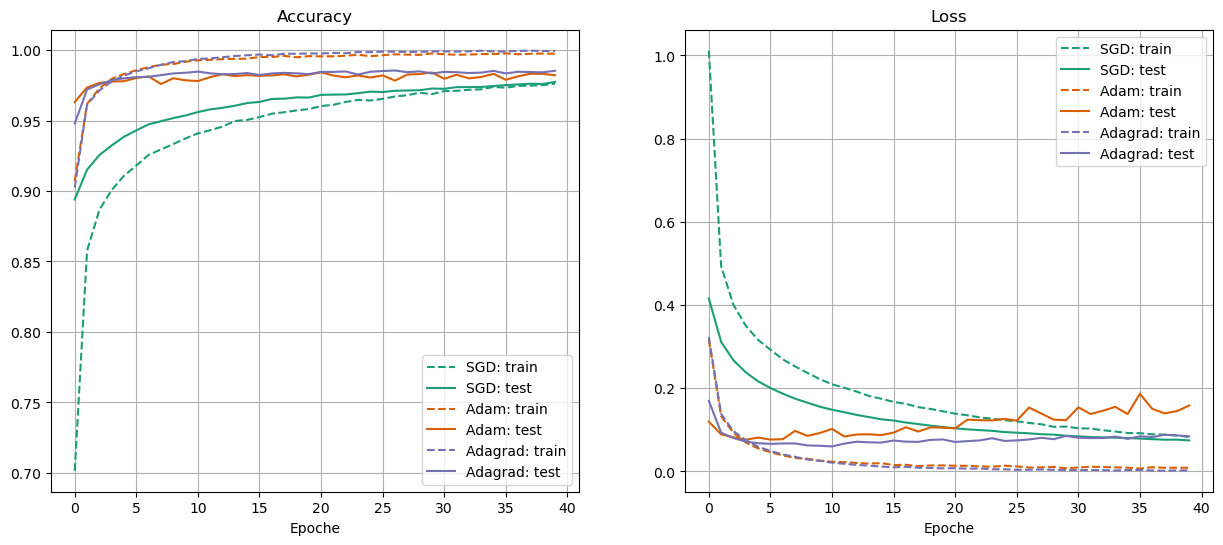

In [34]:
fig,axs=plt.subplots(1,2,figsize=[15,6])




colors=[plt.colormaps['Dark2'](i) for i in range(len(optimizer))]
for i,optimizer in enumerate(optimizers):

    # summarize history for accuracy
    axs[0].plot(histories_DNN[i].history['acc'],"--",color=colors[i],label=f"{optimizer}: train")
    axs[0].plot(histories_DNN[i].history['val_acc'],color=colors[i],label=f"{optimizer}: test")

    axs[0].set_xlabel('Epoche')
    axs[0].legend()
    axs[0].set_title("Accuracy")
    axs[0].grid()

    # summarize history for loss
    axs[1].plot(histories_DNN[i].history['loss'],"--",color=colors[i],label=f"{optimizer}: train")
    axs[1].plot(histories_DNN[i].history['val_loss'],color=colors[i],label=f"{optimizer}: test")
    axs[1].set_xlabel('Epoche')
    axs[1].legend()
    axs[1].set_title("Loss")
    axs[1].grid()



Adam e Adagrad (learning rate=0.1) sembrano comparabili. L'accuracy (simile per i due modelli), sembra appiattirsi a partire dalla ventesima generazione, mentre quella di SGD continua a crescere, pur rimanendo più bassa di Adam e Adagrad. La loss di test di Adagrad tende ad appiattirsi, mentre quella di Adam risale leggermente, mostrando un principio di overfitting. Le loss di training, invece sono comparabili. Per quanto riguarda SGD invece, loss di training e test sono decrescenti e la loss di training è più alta di quella di test: SGD avrebbe bisogno di un maggior numero di epoche di addestramento. 

### <span style="color:DodgerBlue"> Esercizio 12.2 </span>



# Rete neurale CNN

Si vuole ora testare un altro tipo di reti neurali: le CNN, _Convolutional Neural Networks_, molto utilizzate per il riconoscimento delle immagini.

Esse si basano sui principi di località e invarianza traslazionale: le _feature_ caratteristiche di un soggetto si troveranno localizzate nell'immagine, ma in posizioni diverse. Sono costruite con due tipi principali di layers: _Convolutional_ e  _Pooling_.

Ogni layer di una rete convoluzionale con input bidimensionale ha tre numeri caratterizzanti: altezza $H_l$, larghezza $W_l$ e numero di canali $D_l$.
Inizialmente il numero di canali è determinato dal tipo di immagine: un'immagine in scala di grigi ha un solo canale, un'immagine RGB ne ha tre. 
Nei layer interni, invece, i canali rappresentano specifiche caratteristiche dell'immagine. 

Un layer di tipo _convolutional_ dispone di un certo numero $F$ di filtri. Ogni filtro è una collezione di $D_l$ matrici $H_f \times W_f$ di pesi, con 
$D_l$ numero di canali dell'input, in aggiunta ad un bias $b$. Le dimensioni di queste matrici sono solitamente inferiori alle dimensioni dell'input: il filtro agisce su una "finestra" ridotta dei dati. Il funzionamento di un filtro è il seguente: 
- Separatamente su ogni canale $j$, il filtro scansiona una sezione $H_f \times W_f$  dell'input.
- Calcola la somma $S_j=\sum_i x_i w_i$, dove $x_i$ e $w_i$ sono rispettivamente gli input e i pesi associati al canale.  
- Somma $S_j$ su tutti i canali e aggiunge il bias $b$. 

L'operazione di convoluzione consiste nel "trascinare" il filtro su tutto il layer di input, raccogliendo i rispettivi output in un nuovo layer. Tendenzialmente, le sue dimensioni spaziali saranno minori: l'informazione è stata "riassunta". Per quanto riguarda il numero di canali in uscita, corrisponderà al numero di filtri del layer di convoluzione. In questo modo, ogni filtro si specializzerà per riconoscere particolari caratteristiche dell'immagine. 

Per non perdere le informazioni nei bordi del layer di input, talvolta si applica del  _padding_  (aggiunta di input fissati a zero tutt'attorno al layer di input). 


Un'ulteriore sintesi delle informazioni si ottiene tramite i layer di tipo _pooling_. Essi sostituiscono una finestra $H_p \times W_p$ di input con un solo valore, risultato dell'applicazione di un'operazione ai valori di input (ad esempio la media, o l'operazione $\max$). L'operazione viene ripetuta traslando la finestra su tutto il layer di input, solitamente con passi pari alla grandezza della finestra stessa. Ciò riduce di molto le dimensioni. I layer di _pooling_ agiscono separatamente su ogni canale. 




In [35]:
#backend: channel last
X_train_CNN = X_train.reshape(X_train.shape[0], img_rows, img_cols, 1)
X_test_CNN = X_test.reshape(X_test.shape[0], img_rows, img_cols, 1)
input_shape = (img_rows, img_cols, 1)

print('X_train shape:', X_train.shape)
print('Y_train shape:', Y_train.shape)
print()
print(X_train_CNN.shape[0], 'train samples')
print(X_test_CNN.shape[0], 'test samples')

X_train shape: (60000, 28, 28)
Y_train shape: (60000, 10)

60000 train samples
10000 test samples


In [36]:


def create_CNN(optimizer):
    # instantiate model
    model = Sequential()
    model.add(Input(shape=input_shape))
    model.add(Conv2D(10, kernel_size=(5, 5),
                     activation='relu'))
    model.add(MaxPooling2D(pool_size=(2,2)))   

    model.add(Conv2D(20, kernel_size=(3, 3),
                     activation='relu'))
    
    model.add(Flatten())
    model.add(Dropout(0.5))
    model.add(Dense(num_classes, activation='softmax'))

    # compile the model
    model.compile(loss=keras.losses.categorical_crossentropy,
                  optimizer=optimizer,
                  metrics=['acc'])
    return model

### SGD

In [37]:
# create the deep conv net
model_CNN_1=create_CNN(SGD())
model_CNN_1.summary()

# train CNN
history_CNN_1=model_CNN_1.fit(X_train_CNN, Y_train,
          batch_size=batch_size,
          epochs=epochs,
          verbose=1,
          shuffle=True,
          validation_data=(X_test_CNN, Y_test))

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 24, 24, 10)     │           260 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 12, 12, 10)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 10, 10, 20)     │         1,820 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 2000)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 2000)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 10)             │        20,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,090 (86.29 KB)

 Trainable params: 22,090 (86.29 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/40
938/938 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - acc: 0.7265 - loss: 0.8472 - val_acc: 0.9195 - val_loss: 0.2947
Epoch 2/40
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - acc: 0.9059 - loss: 0.3166 - val_acc: 0.9483 - val_loss: 0.1827
Epoch 3/40
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - acc: 0.9348 - loss: 0.2225 - val_acc: 0.9612 - val_loss: 0.1356
Epoch 4/40
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - acc: 0.9474 - loss: 0.1798 - val_acc: 0.9680 - val_loss: 0.1105
Epoch 5/40
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - acc: 0.9536 - loss: 0.1556 - val_acc: 0.9722 - val_loss: 0.0955
Epoch 6/40
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - acc: 0.9587 - loss: 0.1396 - val_acc: 0.9759 - val_loss: 0.0852
Epoch 7/40
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - acc: 0.9617 - loss: 0.1303 - val_acc: 0.9771 - val_loss: 0.0785
Epoch 8/40
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - acc: 0.9646 - loss: 0.1184 - val_acc: 0.9801 - val_loss: 0.0714
Epoch 9/40
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - ac

### Adam

In [38]:
# create the deep conv net
model_CNN_2=create_CNN(Adam())
model_CNN_2.summary()

# train CNN
history_CNN_2=model_CNN_2.fit(X_train_CNN, Y_train,
          batch_size=batch_size,
          epochs=epochs,
          verbose=1, 
          shuffle=True,
          validation_data=(X_test_CNN, Y_test))

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)               │ (None, 24, 24, 10)     │           260 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 12, 12, 10)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 10, 10, 20)     │         1,820 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 2000)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 2000)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 10)             │        20,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,090 (86.29 KB)

 Trainable params: 22,090 (86.29 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/40
938/938 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - acc: 0.9075 - loss: 0.3162 - val_acc: 0.9712 - val_loss: 0.0928
Epoch 2/40
938/938 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - acc: 0.9672 - loss: 0.1121 - val_acc: 0.9823 - val_loss: 0.0578
Epoch 3/40
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - acc: 0.9749 - loss: 0.0834 - val_acc: 0.9857 - val_loss: 0.0464
Epoch 4/40
938/938 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - acc: 0.9782 - loss: 0.0706 - val_acc: 0.9880 - val_loss: 0.0389
Epoch 5/40
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - acc: 0.9805 - loss: 0.0629 - val_acc: 0.9892 - val_loss: 0.0351
Epoch 6/40
938/938 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - acc: 0.9827 - loss: 0.0575 - val_acc: 0.9882 - val_loss: 0.0362
Epoch 7/40
938/938 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - acc: 0.9834 - loss: 0.0536 - val_acc: 0.9890 - val_loss: 0.0346
Epoch 8/40
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - acc: 0.9846 - loss: 0.0496 - val_acc: 0.9902 - val_loss: 0.0311
Epoch 9/40
938/938 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - ac

### Adagrad

In [39]:
# create the deep conv net
model_CNN_3=create_CNN(SGD())
model_CNN_3.summary()

# train CNN
history_CNN_3=model_CNN_3.fit(X_train_CNN, Y_train,
          batch_size=batch_size,
          epochs=epochs,
          verbose=1,
          shuffle=True,
          validation_data=(X_test_CNN, Y_test))

Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_10 (Conv2D)              │ (None, 24, 24, 10)     │           260 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 12, 12, 10)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 10, 10, 20)     │         1,820 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 2000)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 2000)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 10)             │        20,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,090 (86.29 KB)

 Trainable params: 22,090 (86.29 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/40
938/938 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - acc: 0.7465 - loss: 0.7848 - val_acc: 0.9258 - val_loss: 0.2708
Epoch 2/40
938/938 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - acc: 0.9128 - loss: 0.2939 - val_acc: 0.9491 - val_loss: 0.1784
Epoch 3/40
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - acc: 0.9330 - loss: 0.2256 - val_acc: 0.9590 - val_loss: 0.1430
Epoch 4/40
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - acc: 0.9430 - loss: 0.1900 - val_acc: 0.9647 - val_loss: 0.1228
Epoch 5/40
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - acc: 0.9494 - loss: 0.1694 - val_acc: 0.9686 - val_loss: 0.1074
Epoch 6/40
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - acc: 0.9549 - loss: 0.1518 - val_acc: 0.9702 - val_loss: 0.0960
Epoch 7/40
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - acc: 0.9583 - loss: 0.1414 - val_acc: 0.9728 - val_loss: 0.0890
Epoch 8/40
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - acc: 0.9601 - loss: 0.1331 - val_acc: 0.9739 - val_loss: 0.0823
Epoch 9/40
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - ac

In [40]:
optimizers=["SGD","Adam","Adagrad"]
models_CNN=[model_CNN_1,model_CNN_2,model_CNN_3]
histories_CNN=[history_CNN_1,history_CNN_2,history_CNN_3]


for i,optimizer in enumerate(optimizers):
    # evaluate model
    score = models_CNN[i].evaluate(X_test_CNN, Y_test, verbose=1)
    # print performance
    print("Optimizer: ",optimizer)
    print('Test loss:', score[0])
    print('Test accuracy:', score[1],"\n")
  



313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - acc: 0.9897 - loss: 0.0324
Optimizer:  SGD
Test loss: 0.03236328065395355
Test accuracy: 0.9897000193595886 

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - acc: 0.9903 - loss: 0.0327
Optimizer:  Adam
Test loss: 0.03271859139204025
Test accuracy: 0.9902999997138977 

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - acc: 0.9880 - loss: 0.0376
Optimizer:  Adagrad
Test loss: 0.037648722529411316
Test accuracy: 0.9879999756813049 



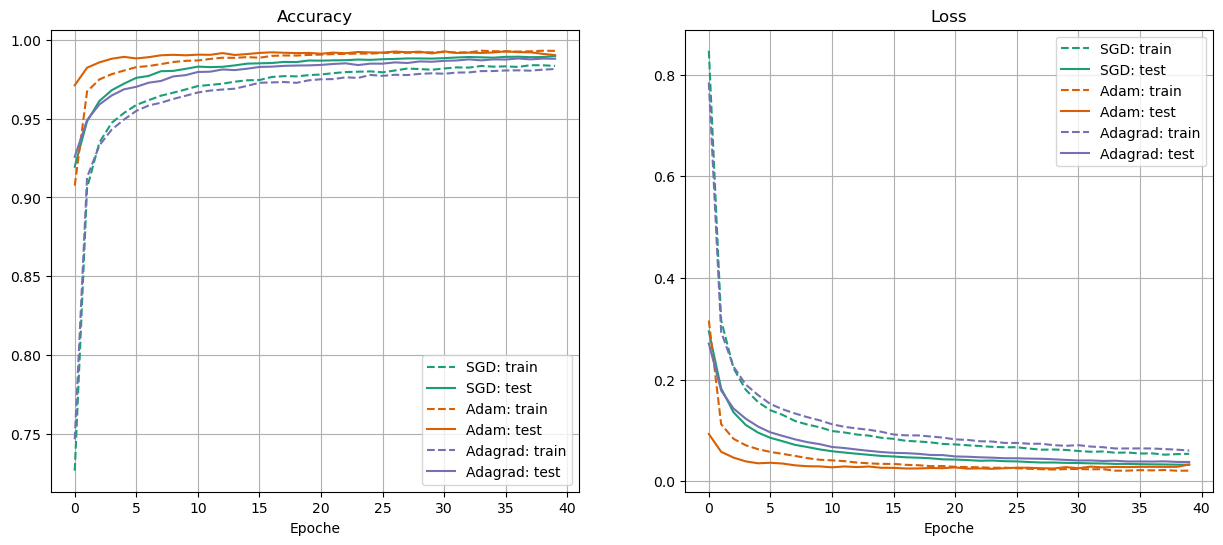

In [41]:
fig,axs=plt.subplots(1,2,figsize=[15,6])



colors=[plt.colormaps['Dark2'](i) for i in range(len(optimizer))]

for i,optimizer in enumerate(optimizers):

    # summarize history for accuracy
    axs[0].plot(histories_CNN[i].history['acc'],"--",color=colors[i],label=f"{optimizer}: train")
    axs[0].plot(histories_CNN[i].history['val_acc'],color=colors[i],label=f"{optimizer}: test")

    axs[0].set_xlabel('Epoche')
    axs[0].legend()
    axs[0].set_title("Accuracy")
    axs[0].grid()

    # summarize history for loss
    axs[1].plot(histories_CNN[i].history['loss'],"--",color=colors[i],label=f"{optimizer}: train")
    axs[1].plot(histories_CNN[i].history['val_loss'],color=colors[i],label=f"{optimizer}: test")
    axs[1].set_xlabel('Epoche')
    axs[1].legend()
    axs[1].set_title("Loss")
    axs[1].grid()


Questa volta, le performance di SGD e AdaGrad (learning rate $0.1$) sono comparabili, mentre Adam appare più veloce. 
Tutti e tre gli optimizer convergono all'incirca allo stesso valore di accuracy (più alta rispetto alla rete DNN) e loss (più bassa). Per SGD e AdaGrad, l'accuracy di test è maggiore rispetto a quella di training, mentre la loss è inferiore. Ciò è segno che bisognerebbe andare avanti con l'addestramento, aumentando il numero di epoche (cosa che non è stata fatta per una questione di tempo di esecuzione). 
Infatti, nonostante contenga meno parametri, la rete CNN ha un tempo di addestramento comparabile con quella DNN, in quanto la complessità delle operazioni come la convoluzione è maggiore. 


### <span style="color:DodgerBlue"> Esercizio 12.3 </span>



Si vuole ora esaminare la performance delle reti appena addestrate su nove cifre scritte a mano da me nello stesso format (sfondo nero-scritta bianca,28x28 pixel) del dataset del Minst. In questo modo si andrà a valutare la capacità di generalizzazione del modello su dati non presenti nel dataset originario.

La cella sottostante implementa la funzione che carica e elabora opportunamente l'immagine di una cifra.

In [42]:

def load_digit(i): 



    digit_filename = f"digits/{i}.png"
    digit_in = Image.open(digit_filename).convert('L')

    ydim, xdim = digit_in.size
    pix=digit_in.load(); 
    data = np.zeros((xdim, ydim))
    for j in range(ydim):
        for i in range(xdim):
            data[i,j]=pix[j,i]


    data /= 255


    return data,xdim,ydim




Le celle sottostanti, invece, si occupano di effettuare la predizione e graficare ogni immagine con la rispettiva cifra predetta. 

### Rete DNN

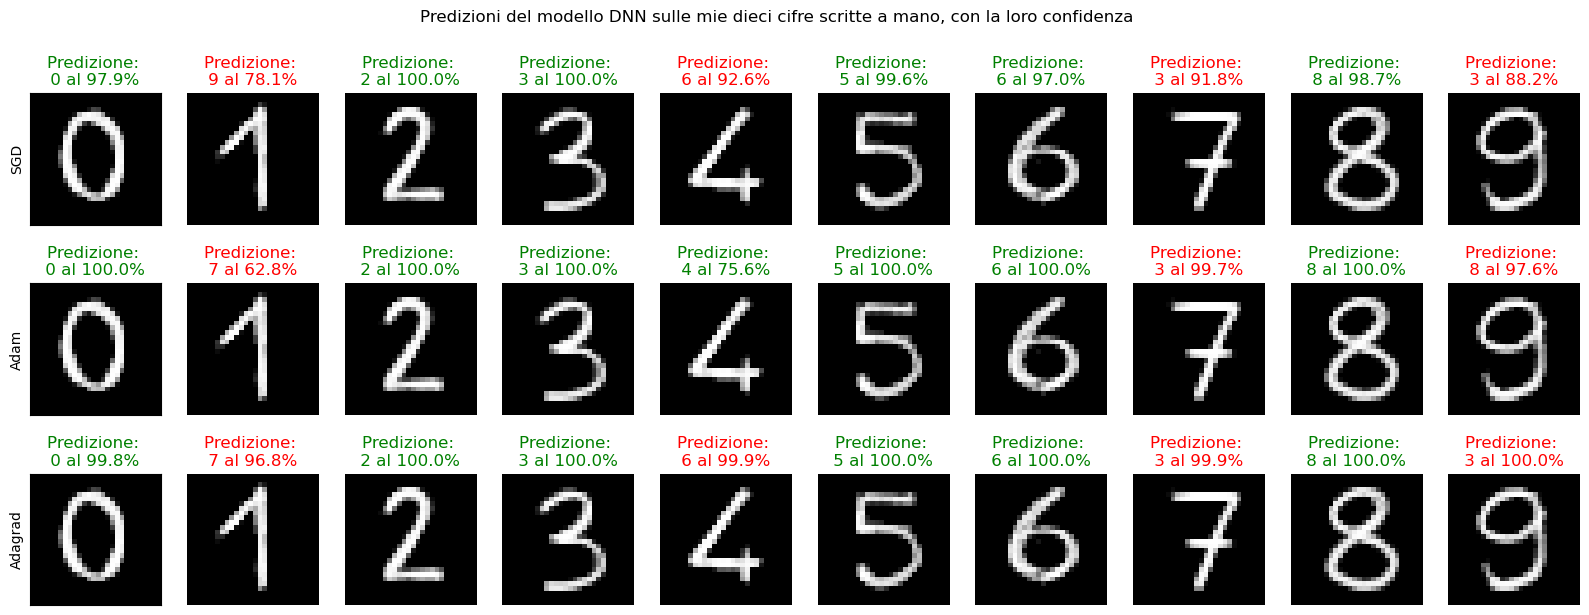

In [43]:

fig,axs=plt.subplots(3,10,figsize=[20,7])


for i,ax in enumerate(axs.T) : #itera sulle cifre

    digit_data,xdim,ydim=load_digit(i) #carica i dati della cifra
    digit_data = digit_data.reshape(1,xdim*ydim) #forma richiesta da una rete DNN

    for j,a in enumerate(ax): #itera sui modelli

        pred= models_DNN[j].predict(digit_data,verbose=0)#predice la cifra (per ogni modello)
        a.imshow(digit_data.reshape(xdim,ydim) , cmap='gray')    # la raffigura


        color="green" if np.argmax(pred)==i else "red" #se la predizione è corretta scrive in verde, altrimenti in rosso
        confidence=100*np.max(pred) #confidenza
        a.set_title(f"Predizione: \n {np.argmax(pred)} al {confidence:.1f}% ",color=color )
        if(i!=0):
            a.axis('off')   

        else:
      
            a.set_xticks([])
            a.set_yticks([])
            a.set_ylabel(f"{optimizers[j]}")






fig.suptitle("Predizioni del modello DNN sulle mie dieci cifre scritte a mano, con la loro confidenza ");

    

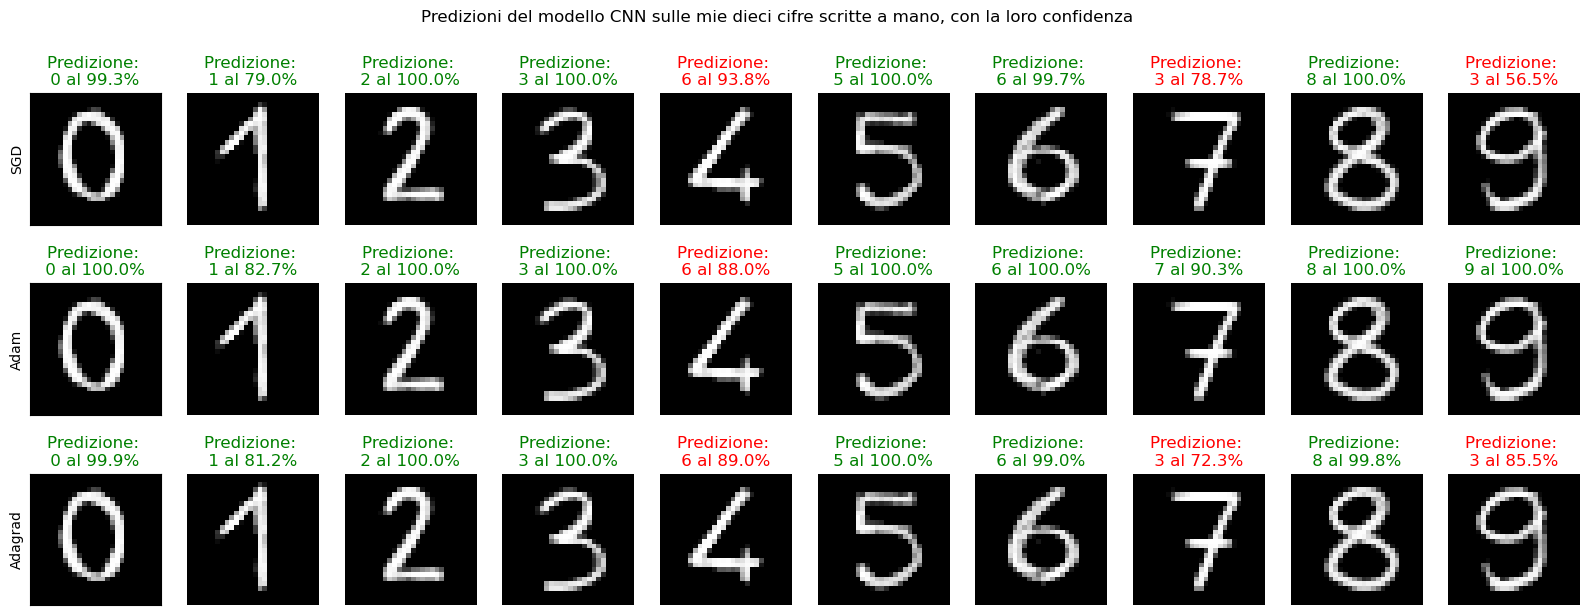

In [44]:

fig,axs=plt.subplots(3,10,figsize=[20,7])


for i,ax in enumerate(axs.T) : #itera sulle cifre

    digit_data,xdim,ydim=load_digit(i) #carica i dati della cifra
    digit_data = digit_data.reshape(1,xdim,ydim,1) # forma richiesta da una rete CNN

    for j,a in enumerate(ax): #itera sui modelli

        pred= models_CNN[j].predict(digit_data,verbose=0)#predice la cifra (per ogni modello)
        a.imshow(digit_data.reshape(xdim,ydim) , cmap='gray')    # la raffigura


        color="green" if np.argmax(pred)==i else "red" #se la predizione è corretta scrive in verde, altrimenti in rosso
        confidence=100*np.max(pred) #confidenza
        a.set_title(f"Predizione: \n {np.argmax(pred)} al {confidence:.1f}% ",color=color )

        if(i!=0):
            a.axis('off')   

        else:
      
            a.set_xticks([])
            a.set_yticks([])
            a.set_ylabel(f"{optimizers[j]}")




fig.suptitle("Predizioni del modello CNN sulle mie dieci cifre scritte a mano, con la loro confidenza ");

    

E' evidente che le predizioni non sono sempre corrette (quattro cifre su dieci sono predette in modo errato almeno una volta) e che la scelta di optimizer influenza il risultato: cifre correttamente predette con un optimizer possono essere predette in modo scorretto con un altro. Ad optimizer fissato, la rete CNN performa tendenzialmente di quella DNN nonostante il numero di parametri sia sedici volte inferiore.


Come verifica, si è provato a riscrivere le quattro cifre che vengono predette in modo errato almeno una volta in modo più conforme alla grafia utilizzata nel dataset originale.

In [45]:

def load_digit_bis(i): 



    digit_filename = f"digits/{i}_bis.png"
    digit_in = Image.open(digit_filename).convert('L')

    ydim, xdim = digit_in.size
    pix=digit_in.load(); 
    data = np.zeros((xdim, ydim))
    for j in range(ydim):
        for i in range(xdim):
            data[i,j]=pix[j,i]


    data /= 255


    return data,xdim,ydim




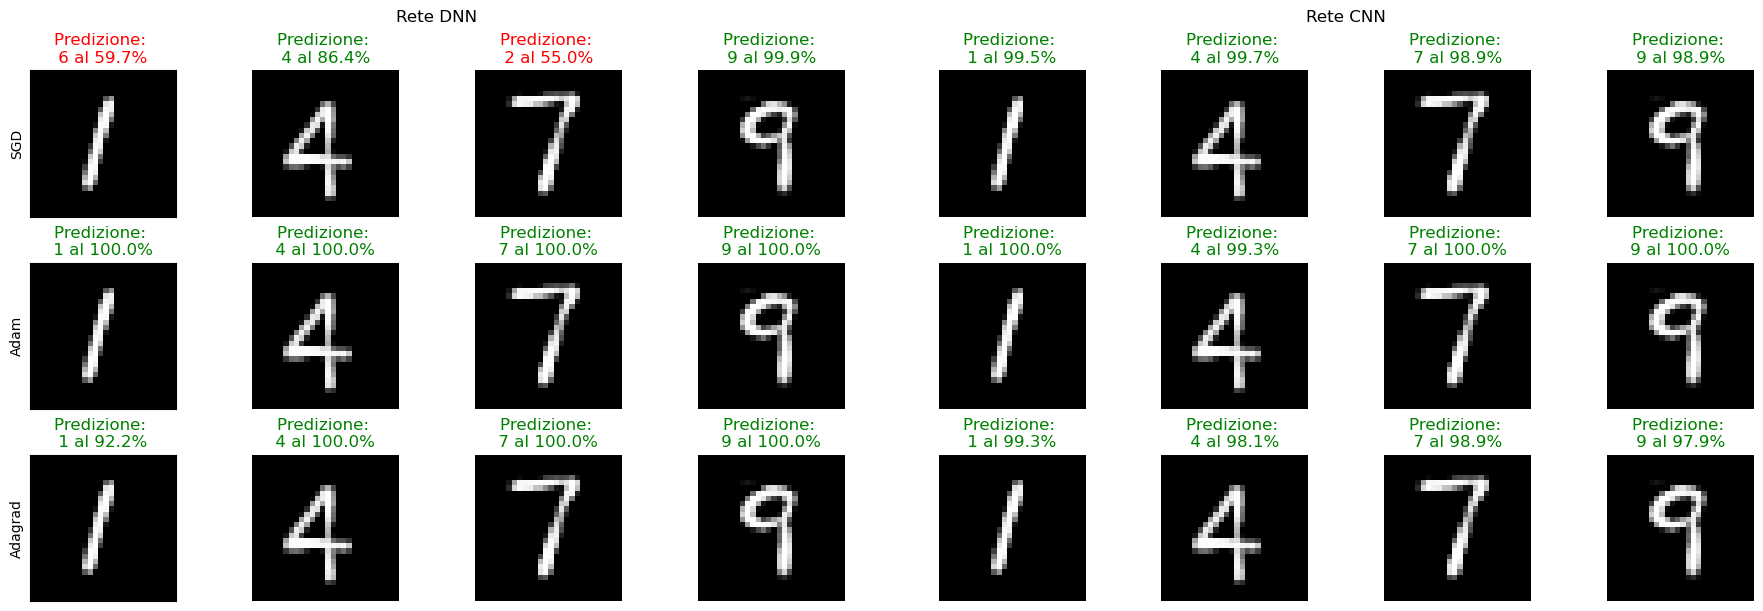

In [46]:


fig=plt.figure(figsize=[18,6],layout='constrained') #figura principale

subfigures=fig.subfigures(1, 2) #crea due sotto figure

#suddivide le due figure
axs1=subfigures[0].subplots(3,4)
axs2=subfigures[1].subplots(3,4)

digits=[1,4,7,9]



#riempie la prima figura, rete DNN

for n,(i,ax) in enumerate(zip(digits,axs1.T)) : #itera sulle cifre

    digit_data,xdim,ydim=load_digit_bis(i) #carica i dati della cifra
    digit_data = digit_data.reshape(1,xdim*ydim) #forma richiesta da una rete DNN

    for j,a in enumerate(ax): #itera sui modelli

        pred= models_DNN[j].predict(digit_data,verbose=0)#predice la cifra (per ogni modello)
        a.imshow(digit_data.reshape(xdim,ydim) , cmap='gray')    # la raffigura


        color="green" if np.argmax(pred)==i else "red" #se la predizione è corretta scrive in verde, altrimenti in rosso
        confidence=100*np.max(pred) #confidenza
        a.set_title(f"Predizione: \n {np.argmax(pred)} al {confidence:.1f}% ",color=color )

        if(n!=0):
            a.axis('off')   

        else:
      
            a.set_xticks([])
            a.set_yticks([])
            a.set_ylabel(f"{optimizers[j]}")





subfigures[0].suptitle("Rete DNN")


#riempie la seconda figura, rete CNN

for i,ax in zip(digits,axs2.T) : #itera sulle cifre

    digit_data,xdim,ydim=load_digit_bis(i) #carica i dati della cifra
    
    digit_data = digit_data.reshape(1,xdim,ydim,1) # forma richiesta da una rete CNN

    for j,a in enumerate(ax): #itera sui modelli

        pred= models_CNN[j].predict(digit_data,verbose=0)#predice la cifra (per ogni modello)
        a.imshow(digit_data.reshape(xdim,ydim) , cmap='gray')    # la raffigura


        color="green" if np.argmax(pred)==i else "red" #se la predizione è corretta scrive in verde, altrimenti in rosso
        confidence=100*np.max(pred) #confidenza
        a.set_title(f"Predizione: \n {np.argmax(pred)} al {confidence:.1f}% ",color=color )

                   
                   
        a.axis('off')   



      


subfigures[1].suptitle("Rete CNN");

    

    

Questa volta le predizioni sono quasi sempre corrette. Nonostante la rete sia capace di generalizzare al di fuori dei dati di training ritiene comunque un bias rispetto ad essi: riconoscerà con più facilità cifre scritte con una grafia più "americana" (e quindi più conforme a quella utilizzata nel dataset). 